In [1]:
!pip install -q -U "bitsandbytes>=0.46.1" accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 39.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 74.6 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Random seed: 42
CUDA available: True
GPU: Tesla T4


In [4]:
DATA_PATH = "/kaggle/input/datasets/amermahbub01/sentifive/SentiFive.csv"

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

N_SAMPLES = 3000
RANDOM_SEED = 42
MAX_NEW_TOKENS = 20

LABELS = [
    "STRONGLY NEGATIVE",
    "SLIGHTLY NEGATIVE",
    "NEUTRAL",
    "SLIGHTLY POSITIVE",
    "STRONGLY POSITIVE"
]

print("Configuration loaded.")
print("Model:", MODEL_NAME)
print("Samples:", N_SAMPLES)

Configuration loaded.
Model: meta-llama/Llama-3.1-8B-Instruct
Samples: 3000


In [5]:
print("Dataset exists:", os.path.exists(DATA_PATH))
print("Dataset path:", DATA_PATH)

Dataset exists: True
Dataset path: /kaggle/input/datasets/amermahbub01/sentifive/SentiFive.csv


In [6]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (31411, 2)

Columns:
['data', 'title']


,data,title
0,থিওরি অফ রিলেটিভিটির প্রেক্ষিতে বাংলা ভাষার এ...,নিশ্চিত ইতিবাচক
1,এডমিনকে অনুরোধ করব যারা এসব কাজ করে দুই বাংলার...,নিরপেক্ষ
2,খাদ্যগলিডেকার্স লেনে ভোজনচর্চা,নিরপেক্ষ
3,আদনান তোর বৌয়ের ভোদা খাবো খুব মিষ্টি রস বেরোয...,নিশ্চিত নেতিবাচক
4,কে কে আমার ভিডিও লাইক করলে,নিরপেক্ষ


In [7]:
print("Unique values in 'title':")
print(df["title"].value_counts(dropna=False))

Unique values in 'title':
title
নিশ্চিত নেতিবাচক    6780
নিশ্চিত ইতিবাচক     6537
নিরপেক্ষ            6453
কিছুটা নেতিবাচক     6006
কিছুটা ইতিবাচক      5635
Name: count, dtype: int64


In [8]:
label_mapping = {
    "নিশ্চিত নেতিবাচক": "STRONGLY NEGATIVE",
    "কিছুটা নেতিবাচক": "SLIGHTLY NEGATIVE",
    "নিরপেক্ষ": "NEUTRAL",
    "কিছুটা ইতিবাচক": "SLIGHTLY POSITIVE",
    "নিশ্চিত ইতিবাচক": "STRONGLY POSITIVE"
}

df["label"] = df["title"].map(label_mapping)

print("Mapped labels:")
print(df["label"].value_counts(dropna=False))

Mapped labels:
label
STRONGLY NEGATIVE    6780
STRONGLY POSITIVE    6537
NEUTRAL              6453
SLIGHTLY NEGATIVE    6006
SLIGHTLY POSITIVE    5635
Name: count, dtype: int64


In [9]:
unknown_labels = df.loc[
    df["label"].isna(),
    "title"
].unique()

if len(unknown_labels) > 0:
    print("Unmapped labels found:")
    print(unknown_labels)
else:
    print("All labels mapped successfully.")

All labels mapped successfully.


In [10]:
eval_df = (
    df.sample(
        n=N_SAMPLES,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)

print("Evaluation dataset shape:", eval_df.shape)
display(eval_df.head())

Evaluation dataset shape: (3000, 3)


,data,title,label
0,আচ্ছা সিকিমে কি কেউ একা ভ্রমন করতে পারবে,নিরপেক্ষ,NEUTRAL
1,রাষ্ট্রীয় কোন বাহিনী পুলিশ কে জখন কোন বিশেষ দল...,কিছুটা নেতিবাচক,SLIGHTLY NEGATIVE
2,ভাই আপনাকে চট্টগ্রামে আসার আমন্ত্রণ রইল,নিশ্চিত ইতিবাচক,STRONGLY POSITIVE
3,ভাই আপনি খাবারের দাম সম্পর্কে একটা ধারনা দেবেন...,নিরপেক্ষ,NEUTRAL
4,সালা কাদের তুই বাল ফালাবি সালা সবার মোবাইল থেক...,নিশ্চিত নেতিবাচক,STRONGLY NEGATIVE


In [11]:
print("Evaluation label distribution:")
print(eval_df["label"].value_counts())

print("\nTotal samples:", len(eval_df))

Evaluation label distribution:
label
STRONGLY NEGATIVE    655
STRONGLY POSITIVE    628
NEUTRAL              606
SLIGHTLY NEGATIVE    578
SLIGHTLY POSITIVE    533
Name: count, dtype: int64

Total samples: 3000


In [12]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

HF_TOKEN = user_secrets.get_secret("gptoss")

print("Hugging Face token loaded successfully.")

Hugging Face token loaded successfully.


In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded successfully.")

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Tokenizer loaded successfully.


In [14]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("4-bit quantization configured.")

4-bit quantization configured.


In [15]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

model.eval()

print("Model loaded successfully.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Model loaded successfully.


In [16]:
if torch.cuda.is_available():

    allocated = torch.cuda.memory_allocated() / (1024 ** 3)
    reserved = torch.cuda.memory_reserved() / (1024 ** 3)

    print(f"GPU memory allocated: {allocated:.2f} GB")
    print(f"GPU memory reserved: {reserved:.2f} GB")

GPU memory allocated: 1.40 GB
GPU memory reserved: 1.51 GB


In [17]:
def zero_shot_messages(text):

    system_prompt = """You are a Bengali sentiment classification system.

Classify the sentiment of the given Bengali text into exactly ONE of these five labels:

STRONGLY NEGATIVE
SLIGHTLY NEGATIVE
NEUTRAL
SLIGHTLY POSITIVE
STRONGLY POSITIVE

Return ONLY the label.
Do not provide explanations.
Do not provide any additional text.
"""

    user_prompt = f"""Bengali text:

{text}

Sentiment label:"""

    return [
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]

In [18]:
sample_text = eval_df.iloc[0]["data"]

messages = zero_shot_messages(sample_text)

print(messages)

[{'role': 'system', 'content': 'You are a Bengali sentiment classification system.\n\nClassify the sentiment of the given Bengali text into exactly ONE of these five labels:\n\nSTRONGLY NEGATIVE\nSLIGHTLY NEGATIVE\nNEUTRAL\nSLIGHTLY POSITIVE\nSTRONGLY POSITIVE\n\nReturn ONLY the label.\nDo not provide explanations.\nDo not provide any additional text.\n'}, {'role': 'user', 'content': 'Bengali text:\n\nআচ্ছা সিকিমে কি কেউ একা ভ্রমন করতে পারবে\n\nSentiment label:'}]


In [19]:
def parse_sentiment(output):

    if output is None:
        return "UNKNOWN"

    text = output.strip().upper()

    # Exact match
    if text in LABELS:
        return text

    # Common formatting variations
    text = text.replace(":", "")
    text = text.replace(".", "")
    text = text.replace("-", " ")

    if text in LABELS:
        return text

    # Check for labels appearing in the output
    for label in LABELS:
        if label in text:
            return label

    # Possible shortened forms
    aliases = {
        "STRONGLY NEGATIVE": [
            "STRONGLY_NEGATIVE",
            "STRONG NEGATIVE"
        ],
        "SLIGHTLY NEGATIVE": [
            "SLIGHTLY_NEGATIVE",
            "MILD NEGATIVE"
        ],
        "NEUTRAL": [
            "NEUTRAL"
        ],
        "SLIGHTLY POSITIVE": [
            "SLIGHTLY_POSITIVE",
            "MILD POSITIVE"
        ],
        "STRONGLY POSITIVE": [
            "STRONGLY_POSITIVE",
            "STRONG POSITIVE"
        ]
    }

    for label, variants in aliases.items():
        for variant in variants:
            if variant in text:
                return label

    return "UNKNOWN"

In [20]:
test_outputs = [
    "STRONGLY NEGATIVE",
    "SLIGHTLY NEGATIVE",
    "NEUTRAL",
    "SLIGHTLY POSITIVE",
    "STRONGLY POSITIVE",
    "The answer is NEUTRAL."
]

for output in test_outputs:
    print(
        f"{output} -> {parse_sentiment(output)}"
    )

STRONGLY NEGATIVE -> STRONGLY NEGATIVE
SLIGHTLY NEGATIVE -> SLIGHTLY NEGATIVE
NEUTRAL -> NEUTRAL
SLIGHTLY POSITIVE -> SLIGHTLY POSITIVE
STRONGLY POSITIVE -> STRONGLY POSITIVE
The answer is NEUTRAL. -> NEUTRAL


In [21]:
def generate_response(messages, max_new_tokens=20):

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_tensors="pt",
        return_dict=True
    )

    # Move all input tensors to the model device
    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    # Remove the original prompt tokens
    input_length = inputs["input_ids"].shape[-1]

    generated_tokens = outputs[0][input_length:]

    response = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return response.strip()

In [22]:
sample_text = eval_df.iloc[0]["data"]

messages = zero_shot_messages(sample_text)

response = generate_response(
    messages,
    max_new_tokens=MAX_NEW_TOKENS
)

prediction = parse_sentiment(response)

print("Bengali text:")
print(sample_text)

print("\nRaw model output:")
print(response)

print("\nParsed prediction:")
print(prediction)

print("\nActual label:")
print(eval_df.iloc[0]["label"])

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Bengali text:
আচ্ছা সিকিমে কি কেউ একা ভ্রমন করতে পারবে

Raw model output:
SLIGHTLY NEGATIVE

Parsed prediction:
SLIGHTLY NEGATIVE

Actual label:
NEUTRAL


In [23]:
predictions = []
raw_outputs = []

print("Starting zero-shot evaluation...\n")

for i, text in enumerate(eval_df["data"]):

    messages = zero_shot_messages(text)

    output = generate_response(
        messages,
        max_new_tokens=MAX_NEW_TOKENS
    )

    prediction = parse_sentiment(output)

    predictions.append(prediction)
    raw_outputs.append(output)

    if (i + 1) % 100 == 0:
        print(
            f"Processed {i + 1}/{len(eval_df)} samples"
        )

print("\nEvaluation completed.")

Starting zero-shot evaluation...

Processed 100/3000 samples
Processed 200/3000 samples
Processed 300/3000 samples
Processed 400/3000 samples
Processed 500/3000 samples
Processed 600/3000 samples
Processed 700/3000 samples
Processed 800/3000 samples
Processed 900/3000 samples
Processed 1000/3000 samples
Processed 1100/3000 samples
Processed 1200/3000 samples
Processed 1300/3000 samples
Processed 1400/3000 samples
Processed 1500/3000 samples
Processed 1600/3000 samples
Processed 1700/3000 samples
Processed 1800/3000 samples
Processed 1900/3000 samples
Processed 2000/3000 samples
Processed 2100/3000 samples
Processed 2200/3000 samples
Processed 2300/3000 samples
Processed 2400/3000 samples
Processed 2500/3000 samples
Processed 2600/3000 samples
Processed 2700/3000 samples
Processed 2800/3000 samples
Processed 2900/3000 samples
Processed 3000/3000 samples

Evaluation completed.


In [24]:
results_df = eval_df.copy()

results_df["prediction"] = predictions
results_df["raw_output"] = raw_outputs

print("Results shape:", results_df.shape)

display(
    results_df[
        ["data", "label", "prediction", "raw_output"]
    ].head(10)
)

Results shape: (3000, 5)


,data,label,prediction,raw_output
0,আচ্ছা সিকিমে কি কেউ একা ভ্রমন করতে পারবে,NEUTRAL,SLIGHTLY NEGATIVE,SLIGHTLY NEGATIVE
1,রাষ্ট্রীয় কোন বাহিনী পুলিশ কে জখন কোন বিশেষ দল...,SLIGHTLY NEGATIVE,SLIGHTLY NEGATIVE,SLIGHTLY NEGATIVE
2,ভাই আপনাকে চট্টগ্রামে আসার আমন্ত্রণ রইল,STRONGLY POSITIVE,SLIGHTLY POSITIVE,SLIGHTLY POSITIVE
3,ভাই আপনি খাবারের দাম সম্পর্কে একটা ধারনা দেবেন...,NEUTRAL,SLIGHTLY NEGATIVE,SLIGHTLY NEGATIVE
4,সালা কাদের তুই বাল ফালাবি সালা সবার মোবাইল থেক...,STRONGLY NEGATIVE,SLIGHTLY NEGATIVE,SLIGHTLY NEGATIVE
5,পাবেনাতো টাকাএটা একটা অবৈধ টাকা হাতানোর পন্থা,STRONGLY POSITIVE,STRONGLY NEGATIVE,STRONGLY NEGATIVE
6,তাদের জন্য এটা কোন বিয়াপার না,SLIGHTLY NEGATIVE,SLIGHTLY NEGATIVE,SLIGHTLY NEGATIVE
7,মিডিয়ার সামনে বিহারিদের মাল লুট হচ্ছে বাহ্,SLIGHTLY NEGATIVE,STRONGLY NEGATIVE,STRONGLY NEGATIVE
8,আমি চিৎকার করে কাঁদিতে চাহিয়া করিতে পারিনি চিৎ...,SLIGHTLY POSITIVE,STRONGLY NEGATIVE,STRONGLY NEGATIVE
9,আপনাদের এই ভ্রমন কোন মাসে ছিল,STRONGLY POSITIVE,NEUTRAL,NEUTRAL


In [25]:
print("Actual labels:", len(results_df["label"]))
print("Predictions:", len(results_df["prediction"]))
print("Raw outputs:", len(results_df["raw_output"]))

assert len(results_df["label"]) == N_SAMPLES
assert len(results_df["prediction"]) == N_SAMPLES

print("\nPrediction count verified.")

Actual labels: 3000
Predictions: 3000
Raw outputs: 3000

Prediction count verified.


In [26]:
y_true = results_df["label"]
y_pred = results_df["prediction"]

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=LABELS,
    average="macro",
    zero_division=0
)

print("===== ZERO-SHOT RESULTS =====")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Macro F1 : {f1:.4f}")

===== ZERO-SHOT RESULTS =====
Accuracy : 0.3230
Precision: 0.3855
Recall   : 0.3211
Macro F1 : 0.2942


In [27]:
report = classification_report(
    y_true,
    y_pred,
    labels=LABELS,
    zero_division=0,
    digits=4
)

print(report)

                   precision    recall  f1-score   support

STRONGLY NEGATIVE     0.4363    0.5176    0.4735       655
SLIGHTLY NEGATIVE     0.2628    0.5848    0.3627       578
          NEUTRAL     0.4800    0.0792    0.1360       606
SLIGHTLY POSITIVE     0.2026    0.2345    0.2174       533
STRONGLY POSITIVE     0.5459    0.1895    0.2813       628

        micro avg     0.3232    0.3230    0.3231      3000
        macro avg     0.3855    0.3211    0.2942      3000
     weighted avg     0.3931    0.3230    0.2982      3000



In [29]:
class_precision, class_recall, class_f1, class_support = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        zero_division=0
    )
)

class_metrics_df = pd.DataFrame({
    "Class": LABELS,
    "Precision": class_precision,
    "Recall": class_recall,
    "F1-Score": class_f1,
    "Support": class_support
})

display(class_metrics_df)

,Class,Precision,Recall,F1-Score,Support
0,STRONGLY NEGATIVE,0.436293,0.517557,0.473464,655
1,SLIGHTLY NEGATIVE,0.262830,0.584775,0.362661,578
2,NEUTRAL,0.480000,0.079208,0.135977,606
3,SLIGHTLY POSITIVE,0.202593,0.234522,0.217391,533
4,STRONGLY POSITIVE,0.545872,0.189490,0.281324,628


In [31]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=LABELS
)

cm_df = pd.DataFrame(
    cm,
    index=LABELS,
    columns=LABELS
)

print("Confusion Matrix:")
display(cm_df)

Confusion Matrix:


,STRONGLY NEGATIVE,SLIGHTLY NEGATIVE,NEUTRAL,SLIGHTLY POSITIVE,STRONGLY POSITIVE
STRONGLY NEGATIVE,339,265,4,31,15
SLIGHTLY NEGATIVE,153,338,10,62,15
NEUTRAL,98,295,48,129,36
SLIGHTLY POSITIVE,108,245,21,125,33
STRONGLY POSITIVE,79,143,17,270,119


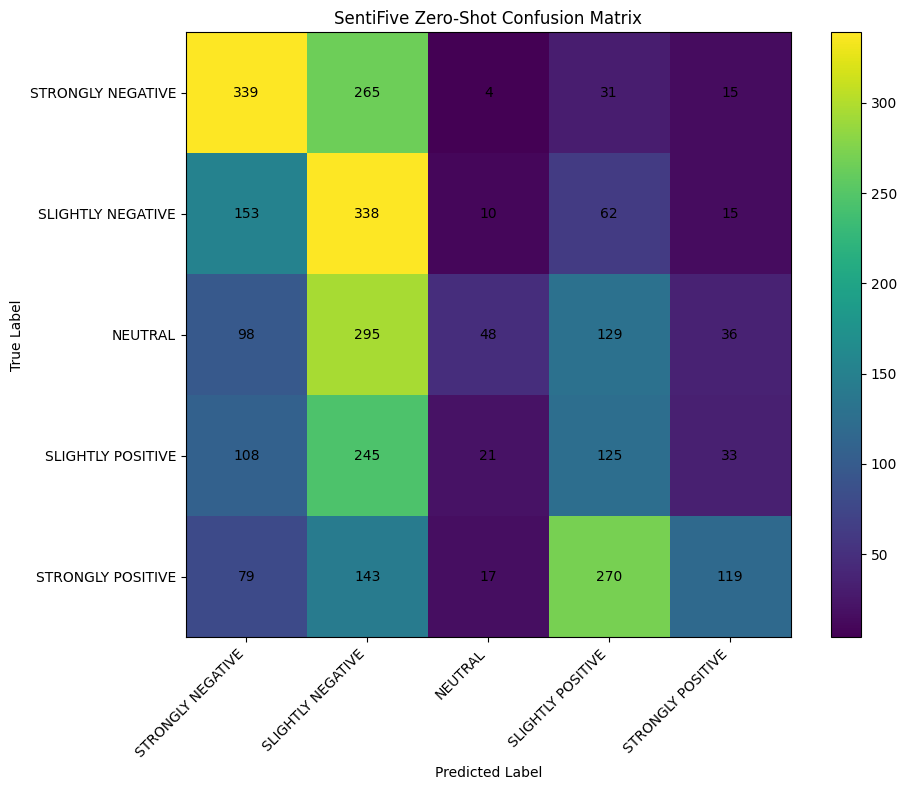

In [32]:
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.xticks(
    range(len(LABELS)),
    LABELS,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(LABELS)),
    LABELS
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SentiFive Zero-Shot Confusion Matrix")

plt.colorbar()

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()